# TN2211 Session 6

## Instruments


In [50]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
import numpy as np

In [51]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('USB0::0xF4EC::0x1017::SDS08A0Q808365::INSTR',)

In [52]:
scope = Scope("SDS")
#gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808365::INSTR
Setting memory depth to 10k points


For this session, we want a 1M memory depth for the spectral analysis:

In [53]:
scope.write("ACQ:MDEP 10k")

## Some handy scope control functions

Save yourself some touchscreen clicks with some of these commnads

Set the frequency display range of the FFT:

In [54]:
def set_freq_range(f1, f2):
    center = (f1+f2)/2
    span = f2-f1
    scope.write("FUNC1:FFT:SPAN %e" % span)
    scope.write("FUNC1:FFT:HCEN %e" % center)

In [55]:
F_max = 1e3
F_min = 0
set_freq_range(F_min, F_max)

Reset the FFT average:

In [56]:
def reset_fft_average():
    scope.write("FUNC1:FFT:RESET")

In [57]:
reset_fft_average()

Set the FFT averaging mode:

In [58]:
def set_fft_averages(n):
    if n == 0:
        scope.write("FUNC1:FFT:MODE NORM")
        return
    if n<4: 
        n = 4 # min allowed number
    if n>1024:
        n = 1024 # max allowed number
    else:
        scope.write("FUNC1:FFT:MODE AVER,%d" % n)

In [59]:
set_fft_averages(10)

Feel free to consult the scope [programming manual](https://nsweb.tn.tudelft.nl/~gsteele/tn2211/programming_manuals/SDS800X%20HD%20Program.%20Guide.pdf) to add some of your own! 

## Aquiring FFTs

Downloading FFT traces from the scope uses a new function in the library called `get_fft()`. By default it will get the FFT stored in function "F1" of the scope:

In [60]:
help(scope.get_fft)

Help on method get_fft in module tn2211_drivers:

get_fft(function_number=1, npoints=<built-in function all>, save_file=True, filename=None) method of tn2211_drivers.Scope instance
    Function for grabbing FFT data from the scope. function_number can be a number
    from 1 to 4. You can use npoints = "all" to grab all the points in the
    trace. By default, it will always grab all the points from the FFT trace

    It will return three things:

    freq, spectrum, unit = get_fft(...)

    freq: the frequency values
    spectrum: the spectral values (in either Vrms, dBVrms, or dBm)
    unit: the setting of the units used on the oscilloscope



In [ ]:
N = 4

set_fft_averages(N)

depth = "50M"

time_base = 1
scope.write(f"ACQ:MDEP {depth}")
scope.write("TIM:SCAL %f" % (time_base))


In [82]:
freq, spectrum, units = scope.get_fft(filename=f"average_{N}_depth_{depth}_Time_scale_{time_base*10}.csv")


Saved to file average_4_depth_50M_Time_scale_0.1.csv


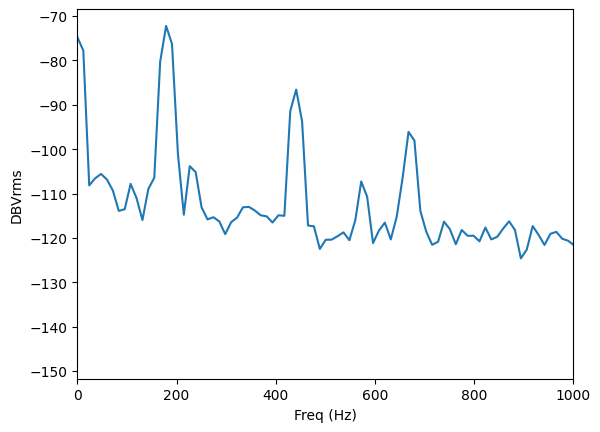

In [79]:
plt.figure()
plt.plot(freq, spectrum)
plt.ylabel(units)
plt.xlabel("Freq (Hz)")
plt.xlim(F_min,F_max)
plt.show()

## Level 2 work

Add your own code and code cells below for your level 2 work. 

In [ ]:
depth = "50M"

time_base = 1/1000
scope.write(f"ACQ:MDEP {depth}")
scope.write("TIM:SCAL %f" % (time_base))


In [84]:
x, t = scope.get_trace(1, filename=f"trace_depth_{depth}.csv")




Saved to file trace_depth_50M.csv


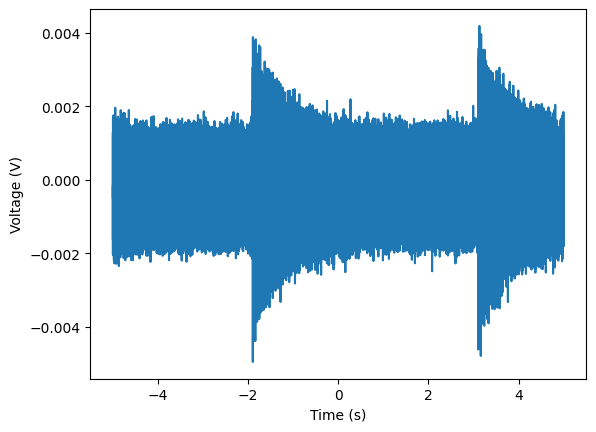

In [47]:
plt.figure()
plt.plot(x, t)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()